### 1.1 Формирование ЛЧМ-импульса на несущей частоте <a id="ch_2_1"></a>

1. Сформировать ЛЧМ-импульс с центральным расположением, воспользовавшись формулой из лекций

$$
s(n) = cos\left( \pi (an^{2}+bn) \right),
$$
где $a=\Delta fT/N_{i}$; $b=2f_{0}T$; $N_{i}$ - длительность импульса в отсчетах; $n$ - последовательность из номеров отсчетов $[-[N{i}/2], ... , -1, 0, 1, ... , [N_{i}/2]]$.  

1. Проверить правильность формы ЛЧМ-сигнала по его спектральным характеристикам: высота спектра должна совпасть со значением, вычисленным по формуле
$$
A_{s}=\frac{A}{2} \sqrt{\frac{N_{i}}{\Delta fT}},
$$
  ширина спектра (на половине высоты) должна соответстовать полосе $\Delta f$, а центральное расположение - несущей частоте $f_{0}$. Фазовый спектр в окрестности центральной частоты должен иметь квадратичный характер (быть похожим на параболу).

53.853140245353515


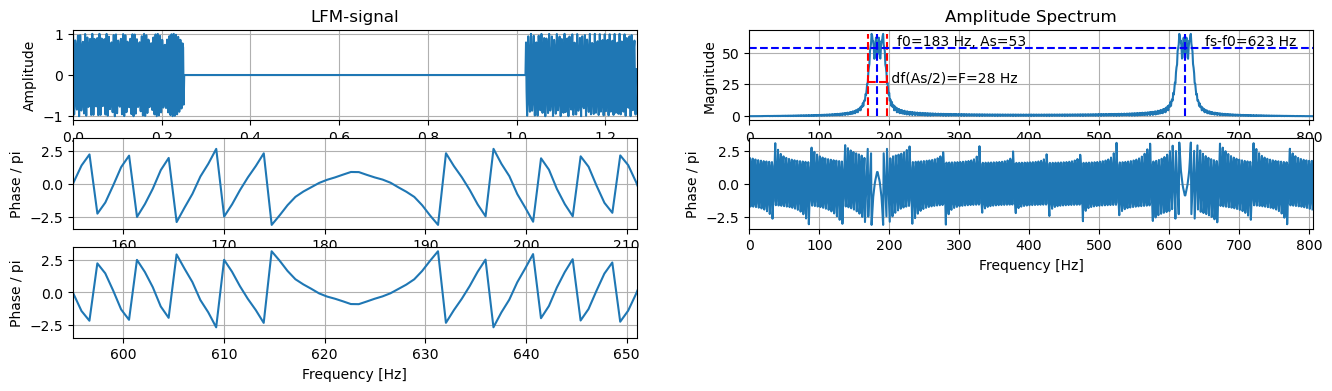

In [321]:
import numpy as np
import matplotlib.pyplot as plt
import math 
import scipy.integrate as spi
from scipy.fftpack import fft, fftfreq, ifft
from scipy.signal import find_peaks
from sympy.solvers import solve
from sympy import Symbol

# Формирование ЛЧМ-импулься с центральным расположением
Num = 3                 # номер по списку
fs = 800 + 2 * Num      # частота дискретизации
f0 = 180 + Num          # центральная частота
df = 25 + Num           # полоса ЛЧМ-сигнала(2 дивиации)
N = 1024                # период сигнала в дискретах
Ni = 400 + Num          # длительность ЛЧМ-сигнала в дискретах
A = Num / 30            # амлитуда отраженного ЛЧМ сигнала
phi0 = 2 * np.pi / Num  # начальная фаза отраженного ЛЧМ-сигнала

# fs   = 25e3    # Частота дискретизации, Гц
# f0   = 3000    # Несущая частота, Гц
# df   = 1200    # Полоса ЛЧМ-сигнала, Гц
# N    = 8192    # Количество дискретов (период сигнала в дискретах)
# Ni   = 1001    # Длительность ЛЧМ-импульса
A    = 1         # Амплитуда исходного сигнала, В

T    = 1 / fs    # Период дискретизации
tau  = N*T       # Период сигнала в секундах

# Оси времени и частоты
tt = np.linspace(0, tau, N, endpoint=False)
ff = np.linspace(0, fs,  N, endpoint=False)

# Последовательность из номеров отсчетов
a = (df * T)/(Ni)
b = 2 * f0 * T
s = np.zeros(N, dtype=complex)
n = np.linspace(math.ceil((- Ni) / 2), (Ni) / 2, Ni, dtype=int)
for i in n:
  s[i % N] = np.cos(np.pi * (a * i ** 2 + b * i))

# Проверка правильности формы ЛЧМ-сигнала по его спектральным характеристикам
As = A / 2 * np.sqrt( Ni / (df * T))
print(As)

# Фазовый спектр
# P = np.pi * df * tau * n ** 2
# P = np.arctan2(np.imag(sft), (np.real(sft)))

# Амплитудный спектр FМ-сигнала
sft = np.abs(fft(s))
P = np.angle(fft(s))
plt.figure(figsize=(16, 4))
plt.subplot(3, 2, 1)
plt.title('LFM-signal')
plt.plot(tt, s)
plt.xlim([0, tau])
plt.grid(True)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.subplot(3, 2, 2)
plt.title('Amplitude Spectrum')
plt.plot(ff, sft)
plt.plot([f0-df/2,f0-df/2],[0, np.max(sft)], 'r--')
plt.plot([f0+df/2,f0+df/2],[0, np.max(sft)], 'r--')
plt.plot([f0-df/2,f0+df/2],[As/2 , As/2 ], 'r--')
plt.plot([f0,f0], [0, np.max(sft)], 'b--')
plt.plot([0,fs],[As, As], 'b--')
plt.annotate(('f0=%d Hz, As=%d'%(f0, As)), (f0+df, As + 2 ))
plt.annotate((' df(As/2)=F=%d Hz'%df), (f0+df/2, As/2 ))
plt.plot([fs-f0,fs-f0], [0, np.max(sft)], 'b--')
plt.annotate(('fs-f0=%d Hz'%(fs-f0)), (fs-f0+df, As + 2 ))
plt.xlim([0, fs]) 
plt.grid(True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')

plt.subplot(3, 2, 4)
plt.plot(ff, P)
plt.grid(True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase / pi')
plt.xlim([0, fs])

plt.subplot(3, 2, 3)
plt.plot(ff, P)
plt.grid(True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase / pi')
plt.xlim([f0-df, f0+df])

plt.subplot(3, 2, 5)
plt.plot(ff, P)
plt.grid(True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase / pi')
plt.xlim([fs-f0-df, fs-f0+df])
plt.show()

plt.show()

### 2.2 Формирование отраженного ЛЧМ-импульса с расположением от нуля <a id="ch_2_2"></a>

1. Сформировать ЛЧМ-импульс с центральным расположением, воспользовавшись формулой из лекций

$$
s_{отр.}(n) = Acos\left( \pi (an^{2}+bn+c) \right),
$$
где $A$ - амплитуда отраженного ЛЧМ-сигнала, $a=\Delta fT/N_{i}$; $b=2f_{0}T-\Delta fT$; $c=\phi_{0} / \pi$; $\phi_{0}$ - начальная фаза отраженного ЛЧМ-сигнала; $N_{i}$ - длительность импульса в отсчетах; $n$ - последовательность из номеров отсчетов $[0, 1, ... , N_{i}-1]$.

2. Проверить правильность формы ЛЧМ-сигнала по его спектральным характеристикам (как это было сделано в п. 3.1). У амплитудного спектра должна измениться только высота (так как изменилась амплитуда исходного сигнала). Фазовый спектр в окрестности центральной частоты близок к линейному с резким наклоном (ветвь параболы).

5.385314024535352


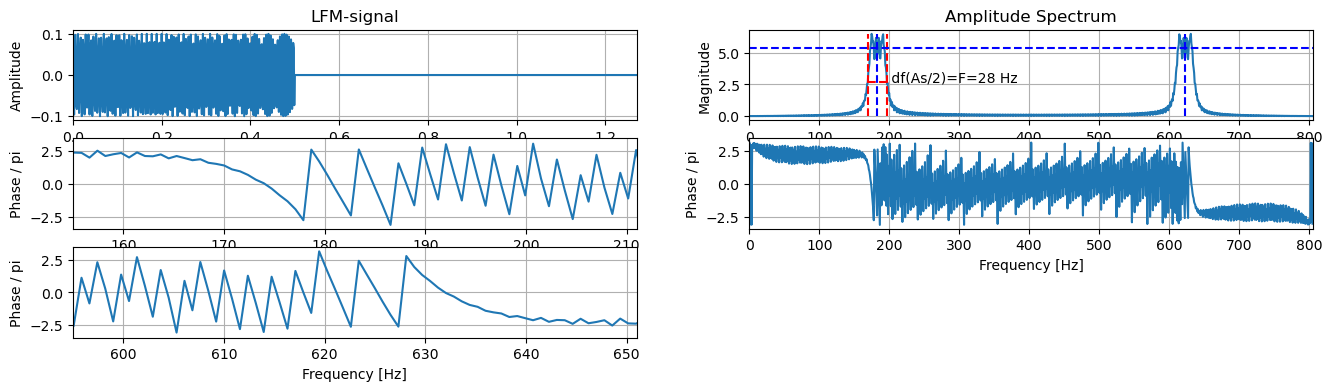

In [322]:
# Формирование ЛЧМ-импулься с центральным расположением
Num = 3                 # номер по списку
fs = 800 + 2 * Num      # частота дискретизации
f0 = 180 + Num          # центральная частота
df = 25 + Num           # полоса ЛЧМ-сигнала(2 дивиации)
N = 1024                # период сигнала в дискретах
Ni = 400 + Num          # длительность ЛЧМ-сигнала в дискретах
A = Num / 30            # амлитуда отраженного ЛЧМ сигнала
phi0 = 2 * np.pi / Num  # начальная фаза отраженного ЛЧМ-сигнала


# fs   = 25e3    # Частота дискретизации, Гц
# f0   = 3000    # Несущая частота, Гц
# df   = 1200    # Полоса ЛЧМ-сигнала, Гц
# N    = 8192    # Количество дискретов (период сигнала в дискретах)
# Ni   = 1001    # Длительность ЛЧМ-импульса
# A    = 0.3     # Амплитуда отраженного сигнала, В
T    = 1 / fs  # Период дискретизации
tau  = N*T     # Период сигнала в секундах
phi0 = np.pi/4 # Начальная фаза отраженного ЛЧМ-сигнала, рад

# Оси времени и частоты
tt = np.linspace(0, tau, N, endpoint=False)
ff = np.linspace(0, fs,  N, endpoint=False)

# Последовательность из номеров отсчетов
a = (df * T)/(Ni)
b = 2 * f0 * T - df* T
c = phi0 / np.pi
s = np.zeros(N, dtype=complex)
n = np.linspace(0, Ni - 1, Ni, dtype=int)
for i in n:
  s[i % N] = A * np.cos(np.pi * (a * (i ** 2) + b * i + c))

# Проверка правильности формы ЛЧМ-сигнала по его спектральным характеристикам
As = A / 2 * np.sqrt( Ni / (df * T))
print(As)

# Фазовый спектр
# P = np.pi * df * tau * n ** 2
# P = np.arctan2(np.imag(sft), (np.real(sft)))

# Амплитудный спектр FМ-сигнала
sft = np.abs(fft(s))
P = np.angle(fft(s))
plt.figure(figsize=(16, 4))
plt.subplot(3, 2, 1)
plt.title('LFM-signal')
plt.plot(tt, s)
plt.xlim([0, tau])
plt.grid(True)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.subplot(3, 2, 2)
plt.title('Amplitude Spectrum')
plt.plot(ff, sft)
plt.plot([f0-df/2,f0-df/2],[0, np.max(sft)], 'r--')
plt.plot([f0+df/2,f0+df/2],[0, np.max(sft)], 'r--')
plt.plot([f0-df/2,f0+df/2],[As/2 , As/2 ], 'r--')
plt.plot([f0,f0], [0, np.max(sft)], 'b--')
plt.plot([0,fs],[As, As], 'b--')
plt.annotate(('f0=%d Hz, As=%d'%(f0, As)), (f0+df, As + 2 ))
plt.annotate((' df(As/2)=F=%d Hz'%df), (f0+df/2, As/2 ))
plt.plot([fs-f0,fs-f0], [0, np.max(sft)], 'b--')
plt.annotate(('fs-f0=%d Hz'%(fs-f0)), (fs-f0+df, As + 2 ))
plt.xlim([0, fs]) # Ограничение оси до частоты Найквиста (только положительная
plt.grid(True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')

plt.subplot(3, 2, 4)
plt.plot(ff, P)
plt.grid(True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase / pi')
plt.xlim([0, fs])

plt.subplot(3, 2, 3)
plt.plot(ff, P)
plt.grid(True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase / pi')
plt.xlim([f0-df, f0+df])

plt.subplot(3, 2, 5)
plt.plot(ff, P)
plt.grid(True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase / pi')
plt.xlim([fs-f0-df, fs-f0+df])
plt.show()

### 2.3 Квадратурная демодуляция, снятие с несущей частоты <a id="ch_2_3"></a>

1. Выполнить квадратурную демодуляцию, домножив отраженный сигнал (полученный в п.3.2) на комплексный гармонический сигнал частотой $f_{0}$:

$$
s_{демод.}(n) = s_{отр.}(n) \cdot e^{-j(2\pi f_{0}nT)},
$$
где $n$ - последовательность из номеров отсчетов $[0, 1, ... , N-1]$.
В результате получится сигнал, для которого одна спектральная составляющая ушла в окрестность 0, а другая - в область высоких частот, которая необходимо отфильтровать при помощи фильтра низких частот (ФНЧ).

2. Спроектировать идеальный ФНЧ в частотной области, задав необходимую ***частоту среза*** $f_{c}$ (необходимо выбрать значение самостоятельно, исходя из получившихся частотных характеристик сигнала).

*ПРИМЕЧАНИЕ*. В данном задании ограничимся идеальным ФНЧ. На практике идеальных частотных характеристик фильтра добиться сложно. Проектированию цифровых фильтров будет посвящена одна из следующих лабораторных работ.

3. Применить ФНЧ к сигналу в частотной области. Построить получившийся спектр и сигнал во временной области. Для перевода сигнала из частотной области во временную, можно воспользоваться функцией *ifft* из пакета *scipy.fftpack*.

5.385314024535352


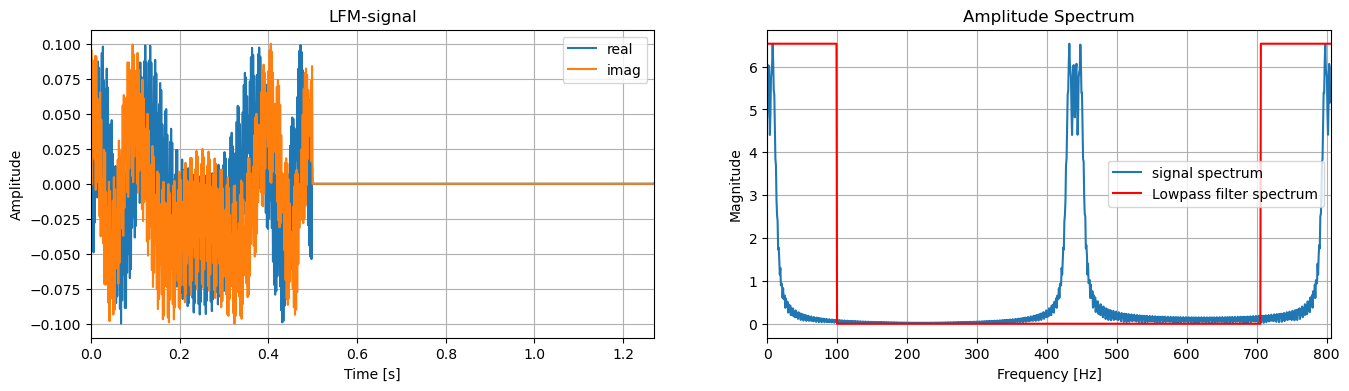

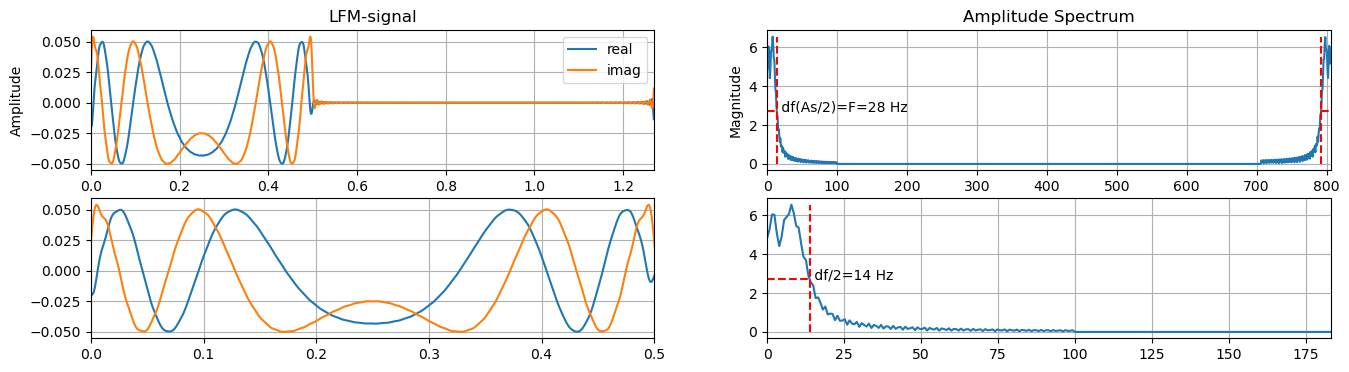

In [323]:
# Формирование ЛЧМ-импулься с центральным расположением
Num = 3                 # номер по списку
fs = 800 + 2 * Num      # частота дискретизации
f0 = 180 + Num          # центральная частота
df = 25 + Num           # полоса ЛЧМ-сигнала(2 дивиации)
N = 1024                # период сигнала в дискретах
Ni = 400 + Num          # длительность ЛЧМ-сигнала в дискретах
A = Num / 30            # амлитуда отраженного ЛЧМ сигнала
phi0 = 2 * np.pi / Num  # начальная фаза отраженного ЛЧМ-сигнала

# fs   = 25e3     # Частота дискретизации, Гц
# f0   = 3000     # Несущая частота, Гц
# df   = 1200     # Полоса ЛЧМ-сигнала, Гц
# N    = 8192     # Количество дискретов (период сигнала в дискретах)
# Ni   = 1001     # Длительность ЛЧМ-импульса
# A    = 0.3      # Амплитуда отраженного сигнала, В
T    = 1 / fs     # Период дискретизации
tau  = N*T        # Период сигнала в секундах
# phi0 = np.pi/4  # Начальная фаза отраженного ЛЧМ-сигнала, рад

# Оси времени и частоты
tt = np.linspace(0, tau, N, endpoint=False)
ff = np.linspace(0, fs,  N, endpoint=False)

# Последовательность из номеров отсчетов
a = (df * T)/(Ni)
b = 2 * f0 * T - df* T
c = phi0 / np.pi
s = np.zeros(N, dtype=complex)
s_demod = np.zeros(N, dtype=complex)
n = np.linspace(0, Ni - 1, Ni, dtype=int)
for i in n:
  s[i % N] = A * np.cos(np.pi * (a * (i ** 2) + b * i + c))
  s_demod[i % N] = s[i % N] * np.exp(-1j * (2 * np.pi * f0 * i * T))

# Квадратурная демодуляция, снятие с несущей частоты
# Проверка правильности формы ЛЧМ-сигнала по его спектральным характеристикам
As = A / 2 * np.sqrt( Ni / (df * T))
print(As)

# Фазовый спектр
# P = np.pi * df * tau * n ** 2
# P = np.arctan2(np.imag(sft), (np.real(sft)))

# Амплитудный спектр FМ-сигнала
sft = np.abs(fft(s_demod))

# Пример реализации идеального ФНЧ в частотной области
lowpass = np.ones(N)
Nc = int(np.round(100*N/fs))
lowpass[Nc:N-Nc] = 0

spec_filtered = fft(s_demod) * lowpass # спектр сигнала после применения ФНЧ
s_filtered = ifft(spec_filtered) # сигнал во временной области после применения ФНЧ

plt.figure(figsize=(16, 4))
plt.subplot(1, 2, 1)
plt.title('LFM-signal')
plt.plot(tt, np.real(s_demod))
plt.plot(tt, np.imag(s_demod))
plt.legend(['real', 'imag'])
plt.xlim([0, tau])
plt.grid(True)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.subplot(1, 2, 2)
plt.title('Amplitude Spectrum')

plt.plot(ff, sft)
plt.xlim([0, fs]) 
plt.plot(ff,lowpass * max(sft), 'r')
plt.legend(['signal spectrum', 'Lowpass filter spectrum'])
plt.grid(True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')

plt.show()

plt.figure(figsize=(16, 4))
plt.subplot(2, 2, 1)
plt.title('LFM-signal')
plt.plot(tt, np.real(s_filtered))
plt.plot(tt, np.imag(s_filtered))
plt.legend(['real', 'imag'])
plt.xlim([0, tau])
plt.grid(True)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.subplot(2, 2, 2)
plt.title('Amplitude Spectrum')

plt.plot(ff, np.abs(spec_filtered))
plt.xlim([0, fs]) 
plt.grid(True)
plt.plot([fs-df/2,fs-df/2],[0, np.max(sft)], 'r--')
plt.plot([0+df/2,0+df/2],[0, np.max(sft)], 'r--')
plt.plot([0,0+df/2],[As/2 , As/2 ], 'r--')
plt.plot([fs-df/2,fs],[As/2 , As/2 ], 'r--')
plt.annotate((' df(As/2)=F=%d Hz'%df), (0+df/2, As/2 ))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')

plt.subplot(2, 2, 3)

x_lim = 0
for i in range(len(s_filtered)):
  if s_filtered[i] == 0:
    x_lim = i
    break
plt.plot(tt, np.real(s_filtered))
plt.plot(tt, np.imag(s_filtered))
xx = 0.55
plt.xlim([0, 0.5])
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(ff, np.abs(spec_filtered))
plt.xlim([0, f0])
plt.grid()
plt.plot([0+df/2,0+df/2],[0, np.max(sft)], 'r--')
plt.plot([0,0+df/2],[As/2 , As/2 ], 'r--')
plt.annotate((' df/2=%d Hz'%(df/2)), (0+df/2, As/2 ))

plt.show()

### 2.4 Формирование сжатого ЛЧМ-сигнала <a id="ch_2_4"></a>

1. Сформировать импульсную характеристику (ИХ, опорный сигнал). ИХ должна быть комплексно сопряженная исходному сигналу с центральным расположением. И так как мы работаем в области низких частот (после снятия с несущей), для ИХ $f_{0}=0$ (в лекциях $S_{base}$ "по центру"), соответственно, коэффициент $b=0$. Начальная фаза опорного сигнала также равна 0, а амплитуда равна 1. Таким образом, для комплексную ИХ можно сформировать по формуле:

$$
h(n) = e^{-j\pi \cdot an^{2} }
$$
где $a=\Delta fT/N_{i}$; $N_{i}$ - длительность импульса в отсчетах; $n$ - последовательность из номеров отсчетов $[-[N{i}/2], ... , -1, 0, 1, ... , [N_{i}/2]]$.  

2. Проверить правильность формы ЛЧМ-сигнала по его спектральным характеристикам: высота спектра должна совпасть со значением, вычисленным по формуле
$$
A_{h}=A\sqrt{\frac{N_{i}}{\Delta fT}},
$$
ширина спектра (на половине высоты) должна соответстовать полосе $\Delta f$, а центральное расположение - точке 0 на оси частот. Фазовый спектр в окрестности центральной частоты должен по-прежнему, иметь квадратичный характер (быть похожим на параболу).


107.70628049070703
[-0.92559782 -0.79759631 -0.57667699 -0.39584581 -0.2039333   0.09446796
  0.44012076  0.78260233  1.28560262  2.03158279  2.78028722 -2.7611451
 -1.82887319 -0.90960658 -0.04047076  1.04562531  2.03931651  3.00978966
 -2.03798356 -1.05982027  0.07043761  1.35605075  2.28588922 -2.5920315
 -1.48787759 -0.46094863  1.09249623  1.95590567 -2.89079661 -1.65360112
 -0.77874223  0.98525667  1.7912981  -3.13293985 -1.72923866 -0.99357026
  0.9154284   1.69381851  2.89525461 -1.77481179 -1.14699975  0.84136133
  1.62811717  2.63114319 -1.8096215  -1.25914145  0.74286851  1.5799403
  2.38954298 -1.84119385]
[-1.34273435 -1.84119385  2.38954298  1.5799403   0.74286851 -1.25914145
 -1.8096215   2.63114319  1.62811717  0.84136133 -1.14699975 -1.77481179
  2.89525461  1.69381851  0.9154284  -0.99357026 -1.72923866 -3.13293985
  1.7912981   0.98525667 -0.77874223 -1.65360112 -2.89079661  1.95590567
  1.09249623 -0.46094863 -1.48787759 -2.5920315   2.28588922  1.35605075
  0.07043

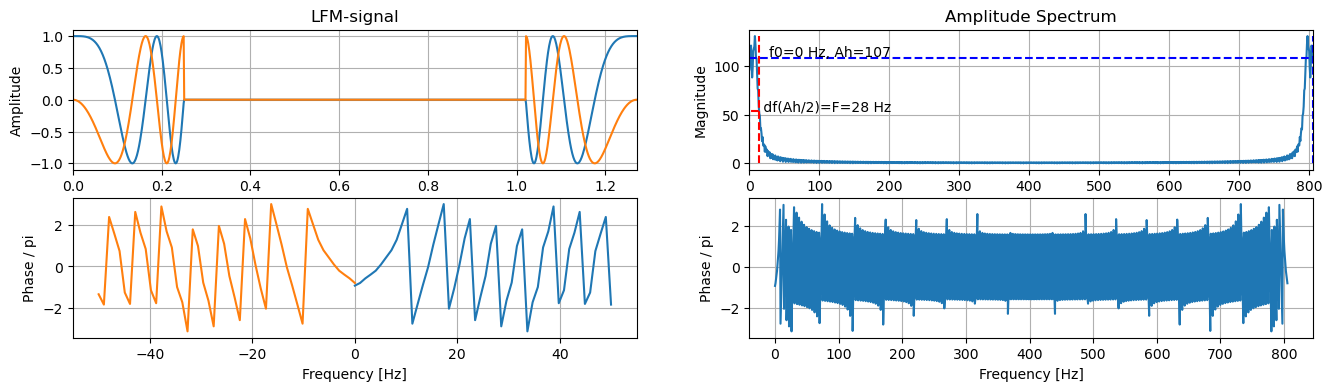

In [324]:
# Формирование ЛЧМ-импулься с центральным расположением
Num = 3                 # номер по списку
fs = 800 + 2 * Num      # частота дискретизации
f0 = 180 + Num          # центральная частота
df = 25 + Num           # полоса ЛЧМ-сигнала(2 дивиации)
N = 1024                # период сигнала в дискретах
Ni = 400 + Num          # длительность ЛЧМ-сигнала в дискретах
A = Num / 30            # амлитуда отраженного ЛЧМ сигнала
phi0 = 2 * np.pi / Num  # начальная фаза отраженного ЛЧМ-сигнала

# fs   = 25000    # Частота дискретизации, Гц
# f0   = 0        # Несущая частота, Гц
# df   = 1200     # Полоса ЛЧМ-сигнала, Гц
# N    = 8192     # Количество дискретов (период сигнала в дискретах)
# Ni   = 1001     # Длительность ЛЧМ-импульса
A    = 1          # Амплитуда отраженного сигнала, В
T    = 1 / fs     # Период дискретизации
tau  = N*T        # Период сигнала в секундах
phi0 = 0          # Начальная фаза отраженного ЛЧМ-сигнала, рад

# Оси времени и частоты
tt = np.linspace(0, tau, N, endpoint=False)
ff = np.linspace(0, fs,  N, endpoint=False)

# Последовательность из номеров отсчетов
a = (df * T)/(Ni)
b = 0
h = np.zeros(N, dtype=complex)
n = np.linspace(math.ceil((- Ni) / 2), (Ni) / 2, Ni,  dtype=int)
for i in n:
  h[i % N] = np.exp(-1j * np.pi * a * i ** 2)

# Квадратурная демодуляция, снятие с несущей частоты
# Проверка правильности формы ЛЧМ-сигнала по его спектральным характеристикам
Ah = A * np.sqrt( Ni / (df * T))
print(Ah)

# Фазовый спектр
# P = np.pi * df * tau * n ** 2
# P = np.arctan2(np.imag(sft), (np.real(sft)))

f0 = 0
# Амплитудный спектр FМ-сигнала
sft = np.abs(fft(h))
P = np.angle(fft(h))
plt.figure(figsize=(16, 4))
plt.subplot(2, 2, 1)
plt.title('LFM-signal')
plt.plot(tt, np.real(h))
plt.plot(tt, np.imag(h))
plt.xlim([0, tau])
plt.grid(True)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.subplot(2, 2, 2)
plt.title('Amplitude Spectrum')
plt.plot(ff, sft)
plt.plot([f0-df/2,f0-df/2],[0, np.max(sft)], 'r--')
plt.plot([f0+df/2,f0+df/2],[0, np.max(sft)], 'r--')
plt.plot([f0-df/2,f0+df/2],[Ah/2 , Ah/2 ], 'r--')
plt.plot([f0,f0], [0, np.max(sft)], 'b--')
plt.plot([0,fs],[Ah, Ah], 'b--')
plt.annotate(('f0=%d Hz, Ah=%d'%(f0, Ah)), (f0+df, Ah + 2 ))
plt.annotate((' df(Ah/2)=F=%d Hz'%df), (f0+df/2, Ah/2 ))
plt.plot([fs-f0,fs-f0], [0, np.max(sft)], 'b--')
plt.annotate(('fs-f0=%d Hz'%(fs-f0)), (fs-f0+df, Ah + 2 ))
plt.xlim([0, fs])
plt.grid(True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')

plt.subplot(2, 2, 4)
plt.plot(ff, P)
plt.grid(True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase / pi')

ddf = int(100/2)

plt.subplot(2, 2, 3)
left  = P[0 : ddf]
right = P[N - ddf : N]
# ff = np.linspace(-len(left), len(right),  len(left) + len(right), endpoint=False)
print(left)
print(right)
plt.plot(np.linspace(0, len(left), len(left), endpoint=True),   left)
plt.plot(np.linspace(-len(right), 0, len(right), endpoint=True), right)
plt.grid(True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase / pi')

plt.show()

3. Сформировать сжатый ЛЧМ-сигнал, воспользовавшись алгоритмом быстрой свертки. Для этого достаточно в частотной области перемножить спектры сигнала, полученного на этапе 3.3 и импульсной характеристики, после чего выполнить ОБПФ.

2.0943951023931953
10.770628049070703
phi= -2.617837908712002
i_max= 201
dt= 0.07142857142857142
t_max= 0.24937965260545905
A_max= 201.50000000000003
abs = 201.42277279902942


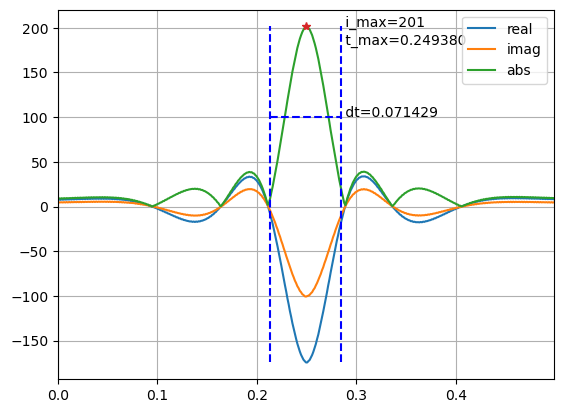

In [325]:
Num = 3                 # номер по списку
fs = 800 + 2 * Num      # частота дискретизации
f0 = 180 + Num          # центральная частота
df = 25 + Num           # полоса ЛЧМ-сигнала(2 дивиации)
N = 1024                # период сигнала в дискретах
Ni = 400 + Num          # длительность ЛЧМ-сигнала в дискретах
A = Num / 30            # амлитуда отраженного ЛЧМ сигнала
phi0 = 2 * np.pi / Num  # начальная фаза отраженного ЛЧМ-сигнала

print(phi0)

# fs   = 25e3     # Частота дискретизации, Гц
# f0   = 3000     # Несущая частота, Гц
# df   = 1200     # Полоса ЛЧМ-сигнала, Гц
# N    = 8192     # Количество дискретов (период сигнала в дискретах)
# Ni   = 1001     # Длительность ЛЧМ-импульса
# A    = 0.3      # Амплитуда отраженного сигнала, В
T    = 1 / fs     # Период дискретизации
tau  = N*T        # Период сигнала в секундах

# Оси времени и частоты
tt = np.linspace(0, tau, N, endpoint=False)
ff = np.linspace(0, fs,  N, endpoint=False)

a = (df * T)/(Ni)
b = 2 * f0 * T - df* T
c = phi0 / np.pi
s = np.zeros(N, dtype=complex)
s_demod = np.zeros(N, dtype=complex)
n = np.linspace(0, Ni - 1, Ni, dtype=int)
for i in n:
  s[i % N] = Am * np.cos(np.pi * (a * (i ** 2) + b * i + c))
  s_demod[i % N] = s[i % N] * np.exp(-1j * (2 * np.pi * f0 * i * T ))

# Амплитудный спектр FМ-сигнала
sft = np.abs(fft(s_demod))

# Пример реализации идеального ФНЧ в частотной области
lowpass = np.ones(N)
Nc = int(np.round(3000*N/fs))
lowpass[Nc:N-Nc] = 0

spec_filtered = fft(s_demod) * lowpass # спектр сигнала после применения ФНЧ
s_filtered = ifft(spec_filtered) # сигнал во временной области после применения ФНЧ

a = (df * T)/(Ni)
b = 0
h = np.zeros(N, dtype=complex)
n = np.linspace(math.ceil((- Ni) / 2), (Ni) / 2, Ni, dtype=int)
for i in n:
  h[i % N] = np.exp(-1j * (np.pi * a * i ** 2 ))

# Квадратурная демодуляция, снятие с несущей частоты
# Проверка правильности формы ЛЧМ-сигнала по его спектральным характеристикам
Ah = A * np.sqrt( Ni / (df * T))
print(Ah)


spec_h = fft(h)
s_compgessed = ifft(spec_filtered * spec_h)

dt = 1 / (0.5 * df)
abs_s_compressed = np.abs(s_compgessed) # Модуль сжатого сигнала
i_max = np.argmax(abs_s_compressed) # Положение максимума сжатого сигнала
phi = np.arctan2(np.imag(s_compgessed[i_max]), np.real(s_compgessed[i_max])) # фаза сжатого сигнала

dt = 1 / (0.5 * df)
t_max = i_max * T

A_s =  Am / 2 * np.sqrt(Ni/(df * T))
A_h = Am * np.sqrt(Ni/(df * T))

A_max = df * T * A_s * A_h

print('phi=',phi)
print('i_max=',i_max)
print('dt=',dt)
print('t_max=',t_max)
print('A_max=',A_max)
print('abs =', np.max(abs_s_compressed))

plt.grid()
plt.plot(tt, np.real(s_compgessed))
plt.plot(tt, np.imag(s_compgessed))
plt.plot(tt, np.abs(s_compgessed))
plt.legend(['real', 'imag', 'abs'])
plt.xlim([0, 2 * t_max])

plt.plot(t_max, np.max(abs_s_compressed),'*')
plt.annotate((' i_max=%d'%(i_max)), (t_max + dt/2,np.max(abs_s_compressed) ))

plt.plot([t_max - dt/2,t_max - dt/2],[np.min(np.real(s_compgessed)), np.max(abs_s_compressed)], 'b--')
plt.plot([t_max + dt/2,t_max + dt/2],[np.min(np.real(s_compgessed)), np.max(abs_s_compressed)], 'b--')
plt.plot([t_max - dt/2,t_max + dt/2],[np.max(abs_s_compressed)/2 , np.max(abs_s_compressed)/2 ], 'b--')
plt.annotate((' dt=%f'%(dt)), (t_max + dt/2,np.max(abs_s_compressed)/2 ))

plt.annotate((' t_max=%f'%(t_max)), (t_max + dt/2,np.max(abs_s_compressed) - 20 ))

plt.show()

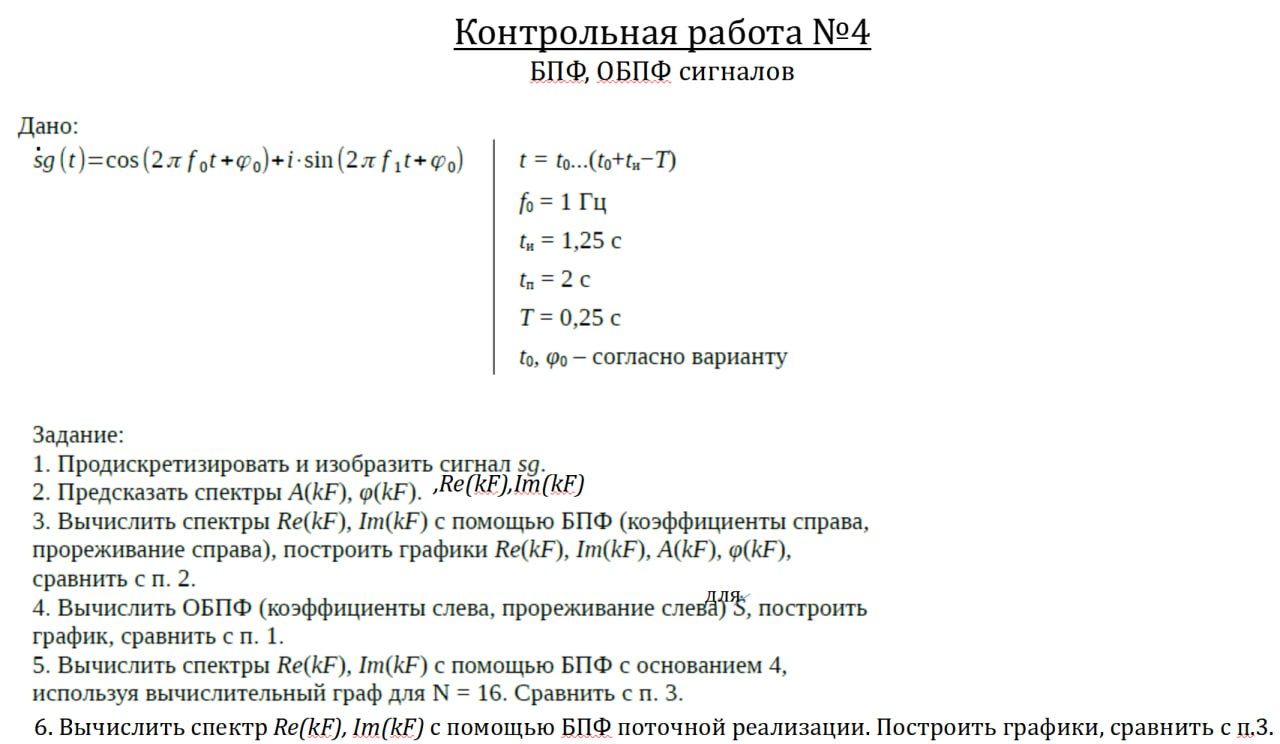

In [326]:
import numpy as np
import sympy
import matplotlib.pyplot as plt

# Служебные переменные
LAST_FIGURE_NUMBER = 0

# Константы
i = complex(0, 1)
pi = np.pi

# Данные по варианту
T = 0.25
t_i = 1.25
t_p = 2
f = 1

t_0 = 0.5
fi_0 = 3 * np.pi/ 4

n_i = t_i / T
n_p = t_p / T
n_0 = t_0 / T

for n in range(-2, 3):
  sg = np.cos(2*pi*f*n*T + fi_0) + 1j * np.sin(2*pi*f*n*T + fi_0)
  print(n, ': ', np.round(sg, 3))

-2 :  (0.707-0.707j)
-1 :  (0.707+0.707j)
0 :  (-0.707+0.707j)
1 :  (-0.707-0.707j)
2 :  (0.707-0.707j)


In [327]:
start_fi = 7*np.pi/4
print('0:')
print('cos:', np.cos(start_fi))
print('sin:', np.sin(start_fi))

print('1:')
print('cos:', np.cos(start_fi - np.pi))
print('sin:', np.sin(start_fi - np.pi))

print('2:')
print('cos:', np.cos(start_fi - np.pi))
print('sin:', np.sin(start_fi - np.pi))

print('3:')
print('cos:', np.cos(start_fi - np.pi))
print('sin:', np.sin(start_fi - np.pi))

print('4:')
print('cos:', np.cos(start_fi - 2*np.pi))
print('sin:', np.sin(start_fi - 2*np.pi))

print('5:')
print('cos:', np.cos(start_fi - 2*np.pi))
print('sin:', np.sin(start_fi - 2*np.pi))

print('6:')
print('cos:', np.cos(start_fi - 3*np.pi))
print('sin:', np.sin(start_fi - 3*np.pi))

print('7:')
print('cos:', np.cos(start_fi - 4*np.pi))
print('sin:', np.sin(start_fi - 4*np.pi))

0:
cos: 0.7071067811865474
sin: -0.7071067811865477
1:
cos: -0.7071067811865475
sin: 0.7071067811865476
2:
cos: -0.7071067811865475
sin: 0.7071067811865476
3:
cos: -0.7071067811865475
sin: 0.7071067811865476
4:
cos: 0.7071067811865476
sin: -0.7071067811865475
5:
cos: 0.7071067811865476
sin: -0.7071067811865475
6:
cos: -0.7071067811865477
sin: 0.7071067811865475
7:
cos: 0.7071067811865477
sin: -0.7071067811865474


### БПФ

In [328]:
sg_list = []

for n in range(8):
  sg = np.cos(2*pi*f*n*T + fi_0) + 1j * np.sin(2*pi*f*n*T + fi_0)
  if n >= 3 and n <= 5:
    sg = 0 + 0j
  sg_list.append(sg)
  print(n, ': ', np.round(sg_list[n], 2))



0 :  (-0.71+0.71j)
1 :  (-0.71-0.71j)
2 :  (0.71-0.71j)
3 :  0j
4 :  0j
5 :  0j
6 :  (0.71-0.71j)
7 :  (0.71+0.71j)


In [329]:
W = np.exp(-1j * np.pi / 4)

stage1 = np.zeros(8, complex)

n = 0
m = 4

for n in range(4):
  stage1[n] = sg_list[n] + sg_list[m]
  stage1[m] = (sg_list[n] - sg_list[m]) * (W ** n)
  # print(f'n = {n}, {np.round(sg_list[n], 2)} + {np.round(sg_list[m], 2)}')
  # print(f'm = {m}, ({np.round(sg_list[n], 2)} - {np.round(sg_list[m], 2)}) * {np.round(W ** n, 2)}')
  m += 1

for n in range(8):
  print(n, ': ', np.round(stage1[n], 2))

0 :  (-0.71+0.71j)
1 :  (-0.71-0.71j)
2 :  (1.41-1.41j)
3 :  (0.71+0.71j)
4 :  (-0.71+0.71j)
5 :  (-1+0j)
6 :  -0j
7 :  (-0+1j)


In [330]:
stage2 = np.zeros(8, complex)

n = 0
m = 2
p = 0

for n in range(0, 2):
  stage2[n] = stage1[n] + stage1[m]
  stage2[m] = (stage1[n] - stage1[m]) * (W ** p)
  # print(f'n = {n}, {np.round(stage1[n], 2)} + {np.round(stage1[m], 2)}')
  # print(f'm = {m}, ({np.round(stage1[n], 2)} - {np.round(stage1[m], 2)}) * {np.round(W ** p, 2)}')
  m += 1
  p += 2

n = 4
m = 6
p = 0

for n in range(4, 6):
  stage2[n] = stage1[n] + stage1[m]
  stage2[m] = (stage1[n] - stage1[m]) * (W ** p)
  # print(f'n = {n}, {np.round(sg_list[n], 2)} + {np.round(sg_list[m], 2)}')
  # print(f'm = {m}, ({np.round(sg_list[n], 2)} - {np.round(sg_list[m], 2)}) * {np.round(W ** p, 2)}')
  m += 1
  p += 2


for n in range(8):
  print(n, ': ', np.round(stage2[n], 2))

0 :  (0.71-0.71j)
1 :  (-0+0j)
2 :  (-2.12+2.12j)
3 :  (-1.41+1.41j)
4 :  (-0.71+0.71j)
5 :  (-1+1j)
6 :  (-0.71+0.71j)
7 :  (-1+1j)


In [331]:
stage3 = np.zeros(8, complex)

n = 0
m = 1

while m < 8:
  stage3[n] = stage2[n] + stage2[m]
  stage3[m] = (stage2[n] - stage2[m]) * (W ** 0)
  # print(f'n = {n}, {np.round(stage2[n], 2)} + {np.round(stage2[m], 2)}')
  # print(f'm = {m}, ({np.round(stage2[n], 2)} - {np.round(stage2[m], 2)}) * {np.round(W ** 0, 2)}')
  m += 2
  n += 2

for n in range(8):
  print(n, ': ', np.round(stage3[n], 2))

0 :  (0.71-0.71j)
1 :  (0.71-0.71j)
2 :  (-3.54+3.54j)
3 :  (-0.71+0.71j)
4 :  (-1.71+1.71j)
5 :  (0.29-0.29j)
6 :  (-1.71+1.71j)
7 :  (0.29-0.29j)


In [332]:
final_sg = []
final_sg.append(stage3[0])
final_sg.append(stage3[4])
final_sg.append(stage3[2])
final_sg.append(stage3[6])
final_sg.append(stage3[1])
final_sg.append(stage3[5])
final_sg.append(stage3[3])
final_sg.append(stage3[7])

for n in range(8):
  print(n, ': ', np.round(final_sg[n], 2))

0 :  (0.71-0.71j)
1 :  (-1.71+1.71j)
2 :  (-3.54+3.54j)
3 :  (-1.71+1.71j)
4 :  (0.71-0.71j)
5 :  (0.29-0.29j)
6 :  (-0.71+0.71j)
7 :  (0.29-0.29j)


In [333]:
for n in range(8):
  print(n, ': ', np.round(abs(final_sg[n]), 2))

0 :  1.0
1 :  2.41
2 :  5.0
3 :  2.41
4 :  1.0
5 :  0.41
6 :  1.0
7 :  0.41


In [334]:
# import cmath

# phase_spectr = []

# for n in range(8):
#   fi = np.imag(final_sg[n]) / np.real(final_sg[n])
#   print(f'{n}: fi = {fi}')
#   phase_spectr.append(np.arctan(fi))
#   # phase_spectr.append(cmath.phase(fi))

# for n in range(8):
#   print(n, ': ', np.round(phase_spectr[n], 2))

### ОБПФ

In [335]:
stage2 = np.zeros(8, complex)

n = 0
m = 1

while m < 8:
  stage2[n] = (stage3[n] + stage3[m] * W ** 0)
  stage2[m] = (stage3[n] - stage3[m] * W ** 0)
  # print(f'n = {n}, {np.round(stage3[n], 2)} + {np.round(stage3[m], 2)} * {np.round(W ** 0, 2)}')
  # print(f'm = {m}, {np.round(stage3[n], 2)} - {np.round(stage3[m], 2)} * {np.round(W ** 0, 2)}')
  n += 2
  m += 2

print()

for n in range(8):
  print(n, ': ', np.round(stage2[n], 2))


0 :  (1.41-1.41j)
1 :  (-0+0j)
2 :  (-4.24+4.24j)
3 :  (-2.83+2.83j)
4 :  (-1.41+1.41j)
5 :  (-2+2j)
6 :  (-1.41+1.41j)
7 :  (-2+2j)


In [336]:
stage1 = np.zeros(8, complex)

n = 0
m = 2
p = 0

for n in range(0, 2):
  stage1[n] = stage2[n] + stage2[m] * (W ** (-p))
  stage1[m] = stage2[n] - stage2[m] * (W ** (-p))
  # print(f'n = {n}, {np.round(stage2[n], 2)} + {np.round(stage2[m], 2)} * {np.round(W ** (-p), 2)}')
  # print(f'm = {m}, {np.round(stage2[n], 2)} - {np.round(stage2[m], 2)} * {np.round(W ** (-p), 2)}')
  m += 1
  p += 2

n = 4
m = 6
p = 0

for n in range(4, 6):
  stage1[n] = stage2[n] + stage2[m] * (W ** (-p))
  stage1[m] = stage2[n] - stage2[m] * (W ** (-p))
  # print(f'n = {n}, {np.round(stage2[n], 2)} + {np.round(stage2[m], 2)} * {np.round(W ** (-p), 2)}')
  # print(f'm = {m}, {np.round(stage2[n], 2)} - {np.round(stage2[m], 2)} * {np.round(W ** (-p), 2)}')
  m += 1
  p += 2

print()

for n in range(8):
  print(n, ': ', np.round(stage1[n], 2))


0 :  (-2.83+2.83j)
1 :  (-2.83-2.83j)
2 :  (5.66-5.66j)
3 :  (2.83+2.83j)
4 :  (-2.83+2.83j)
5 :  (-4+0j)
6 :  -0j
7 :  (-0+4j)


In [337]:
orig_sg = np.zeros(8, complex)

n = 0
m = 4

for n in range(4):
  orig_sg[n] = stage1[n] + stage1[m] * (W ** (-n))
  orig_sg[m] = stage1[n] - stage1[m] * (W ** (-n))
  # print(f'n = {n}, {np.round(stage1[n], 2)} + {np.round(stage1[m], 2)} * {np.round(W ** (-n), 2)}')
  # print(f'm = {m}, {np.round(stage1[n], 2)} - {np.round(stage1[m], 2)} * {np.round(W ** (-n), 2)}')
  m += 1

print()

for n in range(8):
  print(n, ': ', np.round(orig_sg[n], 2))

print()

for n in range(8):
  orig_sg[n] = orig_sg[n] / 8
  print(n, ': ', np.round(orig_sg[n], 2))


0 :  (-5.66+5.66j)
1 :  (-5.66-5.66j)
2 :  (5.66-5.66j)
3 :  0j
4 :  -0j
5 :  (-0-0j)
6 :  (5.66-5.66j)
7 :  (5.66+5.66j)

0 :  (-0.71+0.71j)
1 :  (-0.71-0.71j)
2 :  (0.71-0.71j)
3 :  0j
4 :  -0j
5 :  (-0-0j)
6 :  (0.71-0.71j)
7 :  (0.71+0.71j)
